<a href="https://colab.research.google.com/github/olihile84-tech/exercise-syntax-variables-and-numbers/blob/main/Variables_and_Numbers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install git+https://github.com/Kaggle/learntools.git

  Cloning https://github.com/Kaggle/learntools.git to /tmp/pip-req-build-qhxybcvj
  Running command git clone --filter=blob:none --quiet https://github.com/Kaggle/learntools.git /tmp/pip-req-build-qhxybcvj
  Resolved https://github.com/Kaggle/learntools.git to commit a0c08ac1fa73dd42ba4aecf2cce045752f14f72b
  Preparing metadata (setup.py) ... done


In [ ]:
from learntools. core import binder; binder.bind(globals())
from learntools.python.ex7 import *
print('Setup complete')

Setup complete


<Axes: >

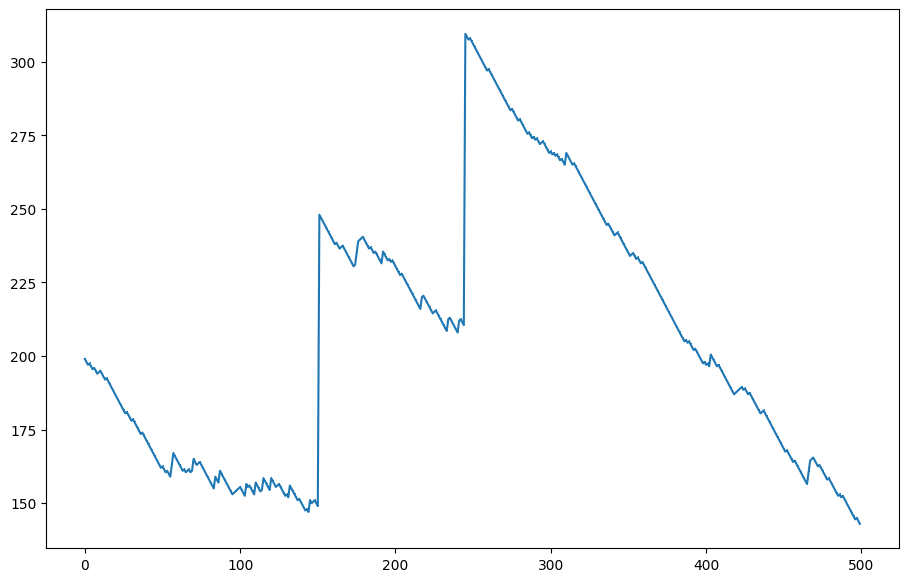

In [ ]:
from learntools.python import jimmy_slots

graph = jimmy_slots.get_graph()
graph

<Axes: title={'center': 'Results of $500 slot machine pulls'}, ylabel='Balance'>

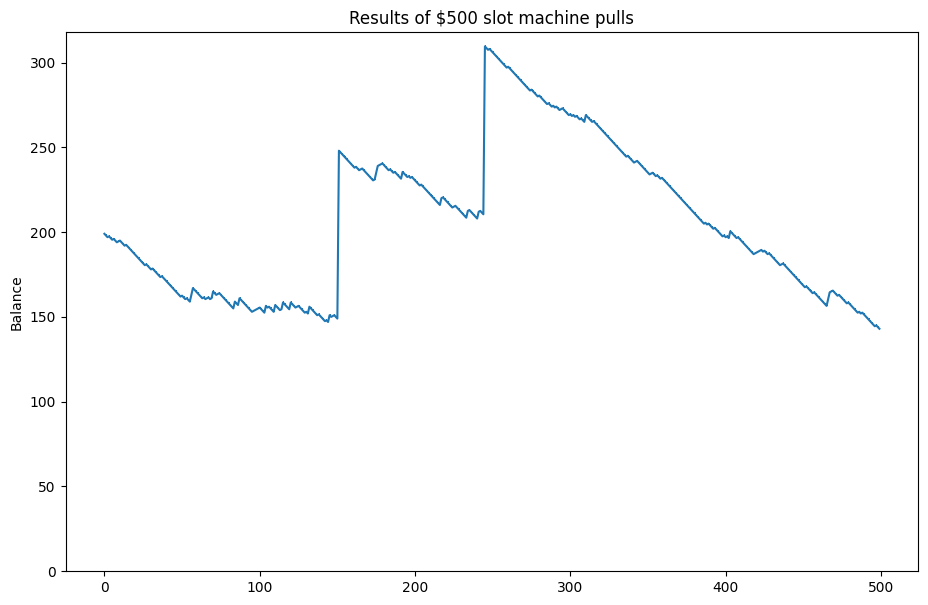

In [ ]:
def prettify_graph(graph):
  graph.set_title("Results of $500 slot machine pulls")
  graph.set_ylim(0)
  graph.set_ylabel("Balance")

graph = jimmy_slots.get_graph()
prettify_graph(graph)
graph


/tmp/ipykernel_8407/2787712327.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  graph.set_yticklabels(new_labels)


<Axes: title={'center': 'Result of 500 slot machine pulls'}, ylabel='Balance'>

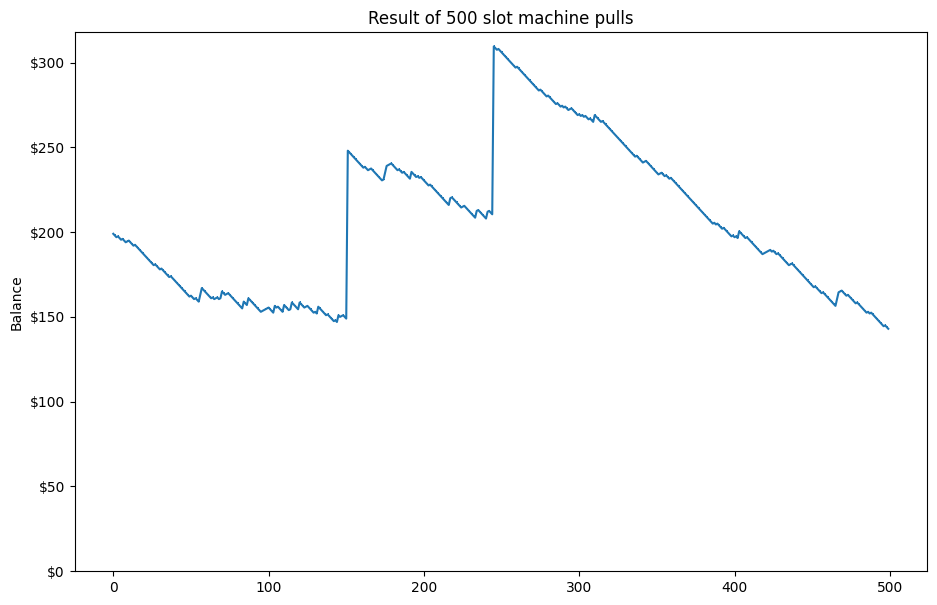

In [ ]:
def prettify_graph(graph):
  graph.set_title("Result of 500 slot machine pulls")
  graph.set_ylim(0)
  graph.set_ylabel("Balance")
  ticks= graph.get_yticks()
  new_labels=['${}'.format(int(amt))for amt in ticks]
  graph.set_yticklabels(new_labels)

from learntools.python import jimmy_slots
graph = jimmy_slots.get_graph()
prettify_graph(graph)
graph

In [ ]:
def best_items(racers):
  winner_item_counts={}
  for x in range(len(racers)):
    racer=racers[x]
    if racer['finsh']==1:
      for x in racer['items']:
        if x not in winner_item_counts:
          winner_item_counts[x]=0
          winner_item_counts[x]+=1

        if racer['name'] is None:
          print("WARING: Encountered racer with known name on iteation {}/{} (racer = {})".format(
          i+1, len(racers), racer['name'])
          )

  return winner_item_counts

q2.check()




<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

Luigi used the variable name `i` to represent each item in racer['items'].
However, he also used `i` as the loop variable for the outer loop (`for i in range(len(racers))`).
These i's are clobbering each other. This becomes a problem only if we encounter a racer
with a finish of 1 and a name of `None`. If that happens, when we try to print the "WARNING" message,
`i` refers to a string like "green shell", which python can't add to an integer, hence a `TypeError`.

This is similar to the issue we saw when we imported * from `math` and `numpy`. They both contained variables called `log`, and the one we got when we tried to call it was the wrong one.

We can fix this by using different loop variables for the inner and outer loops. `i` wasn't a very
good variable name for the inner loop anyways. `for item in racer['items']` fixes the bug and is 
easier to read.

Variable shadowing bugs like this don't come up super often, but when they do they can take an infuriating amount of time to diagnose!


In [ ]:
def blackjack_hand_greater_than(hand_1, hand_2):
  def hand_total(hand):
    total = 0
    aces = 0
    for card in hand:
      if card in ['J', 'Q', 'K']:
        total += 10
      elif card == 'A':
         aces += 1
         total += 11
      else:
        total += int(card)
    while total > 21 and aces>0:
      total -= 10
      aces -= 1
    return total

  total_1 = hand_total(hand_1)
  total_2 = hand_total(hand_2)
  if total_1>21:
    return False
  if total_2>21:
    return True
  return total_1>total_2

q3.check()



<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
def blackjack_hand_greater_than(hand_1, hand_2):
    def hand_total(hand):
        total = 0
        aces = 0
        for card in hand:
            if card in ['J', 'Q', 'K']:
                total += 10
            elif card == 'A':
                aces += 1
                total += 11
            else:
                total += int(card)
        while total > 21 and aces > 0:  # ← outside the for loop
            total -= 10
            aces -= 1
        return total                     # ← outside the for loop too

    total_1 = hand_total(hand_1)         # ← back in the outer function
    total_2 = hand_total(hand_2)
    if total_1 > 21:
        return False
    if total_2 > 21:
        return True
    return total_1 > total_2

q3.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>